In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iris' dataset.
Path to dataset files: /kaggle/input/iris


In [11]:
import pandas as pd

# Path from kagglehub
path = "/kaggle/input/iris/Iris.csv"

# Load dataset
df = pd.read_csv(path)
print(df.head())


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [12]:
print(df.shape)   # should be (150, 5)
print(df['Species'].value_counts())


(150, 6)
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [13]:
X = df.drop(['Species','Id'], axis=1)
Y = df['Species']

In [14]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()
Y_enc = encoder.fit_transform(Y)
Y_cat = to_categorical(Y_enc)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y_cat, test_size=0.2, random_state=42)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(10, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.6583 - loss: 0.9533 - val_accuracy: 0.7000 - val_loss: 0.9240
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6583 - loss: 0.9269 - val_accuracy: 0.7000 - val_loss: 0.8951
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6583 - loss: 0.9007 - val_accuracy: 0.7000 - val_loss: 0.8743
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6583 - loss: 0.8814 - val_accuracy: 0.7000 - val_loss: 0.8601
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6583 - loss: 0.8679 - val_accuracy: 0.7000 - val_loss: 0.8489
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6583 - loss: 0.8567 - val_accuracy: 0.7000 - val_loss: 0.8361
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6583 - loss: 0.8446 - val_accuracy: 0.7000 - val_loss: 0.8215
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6583 - loss: 0.8311 - val_accuracy: 0.7000 - val_loss:

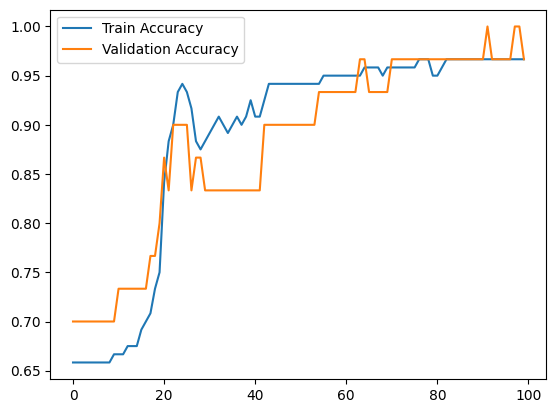

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.show()


In [22]:
# Drop index column
X = df.drop(['Species', 'Id'], axis=1)
Y = df['Species']

# Encode labels
encoder = LabelEncoder()
Y_enc = encoder.fit_transform(Y)
Y_cat = to_categorical(Y_enc)
from sklearn.preprocessing import StandardScaler
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_cat, test_size=0.2, random_state=42)

# Build model
model = Sequential([
    Dense(10, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.2833 - loss: 1.1687 - val_accuracy: 0.3333 - val_loss: 1.1039
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3250 - loss: 1.1448 - val_accuracy: 0.3667 - val_loss: 1.0790
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3333 - loss: 1.1219 - val_accuracy: 0.3667 - val_loss: 1.0554
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3167 - loss: 1.1007 - val_accuracy: 0.3333 - val_loss: 1.0326
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3417 - loss: 1.0802 - val_accuracy: 0.3667 - val_loss: 1.0105
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3417 - loss: 1.0611 - val_accuracy: 0.3667 - val_loss: 0.9891
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3333 - loss: 1.0436 - val_accuracy: 0.3667 - val_loss: 0.9684
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3333 - loss: 1.0258 - val_accuracy: 0.3667 - val_loss:

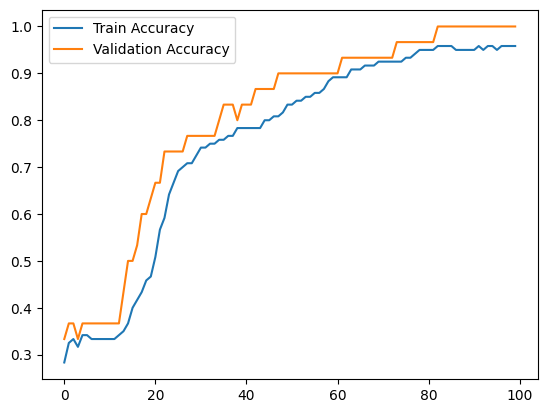

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.show()
